In [2]:
import sys
import os

# !pip install pandas
# !pip install seaborn
# !pip install qiskit-aer
import pandas as pd
import numpy as np

import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skewnorm, t, chi2, gamma
from scipy.stats import kstest
import json
import math

from qiskit.synthesis import LieTrotter
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian
from qiskit_addon_utils.problem_generators import generate_time_evolution_circuit
from qiskit.quantum_info import SparsePauliOp

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'utils'))
if src_path not in sys.path:
    sys.path.append(src_path)

from qiskit_addon_obp.classical_shadows import run_shadow, calculate_shadow_sample_complexity
from qiskit_addon_obp.run import run_many, obp_protocol
from qiskit_addon_obp.obp import run_backpropagation

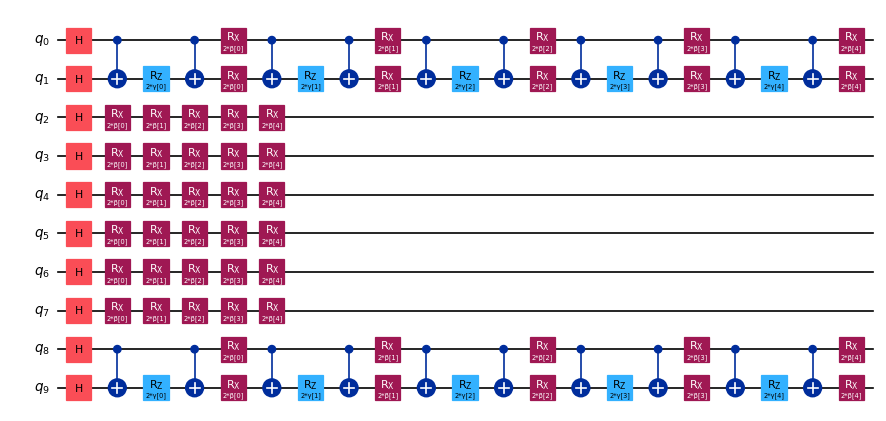

In [8]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
import rustworkx as rx
from qiskit.compiler import transpile

observables = ["ZZIIIIIIII", "IIIIIIIIZZ"]
coeffs = [1.0] * len(observables)
circuit = QAOAAnsatz(cost_operator=SparsePauliOp(observables, coeffs), reps=5)
circuit = transpile(circuit, basis_gates=['cx', 'rz', 'rx', 'h'])

circuit.draw("mpl", style="iqp", scale=0.6)
# print(circuit.depth())

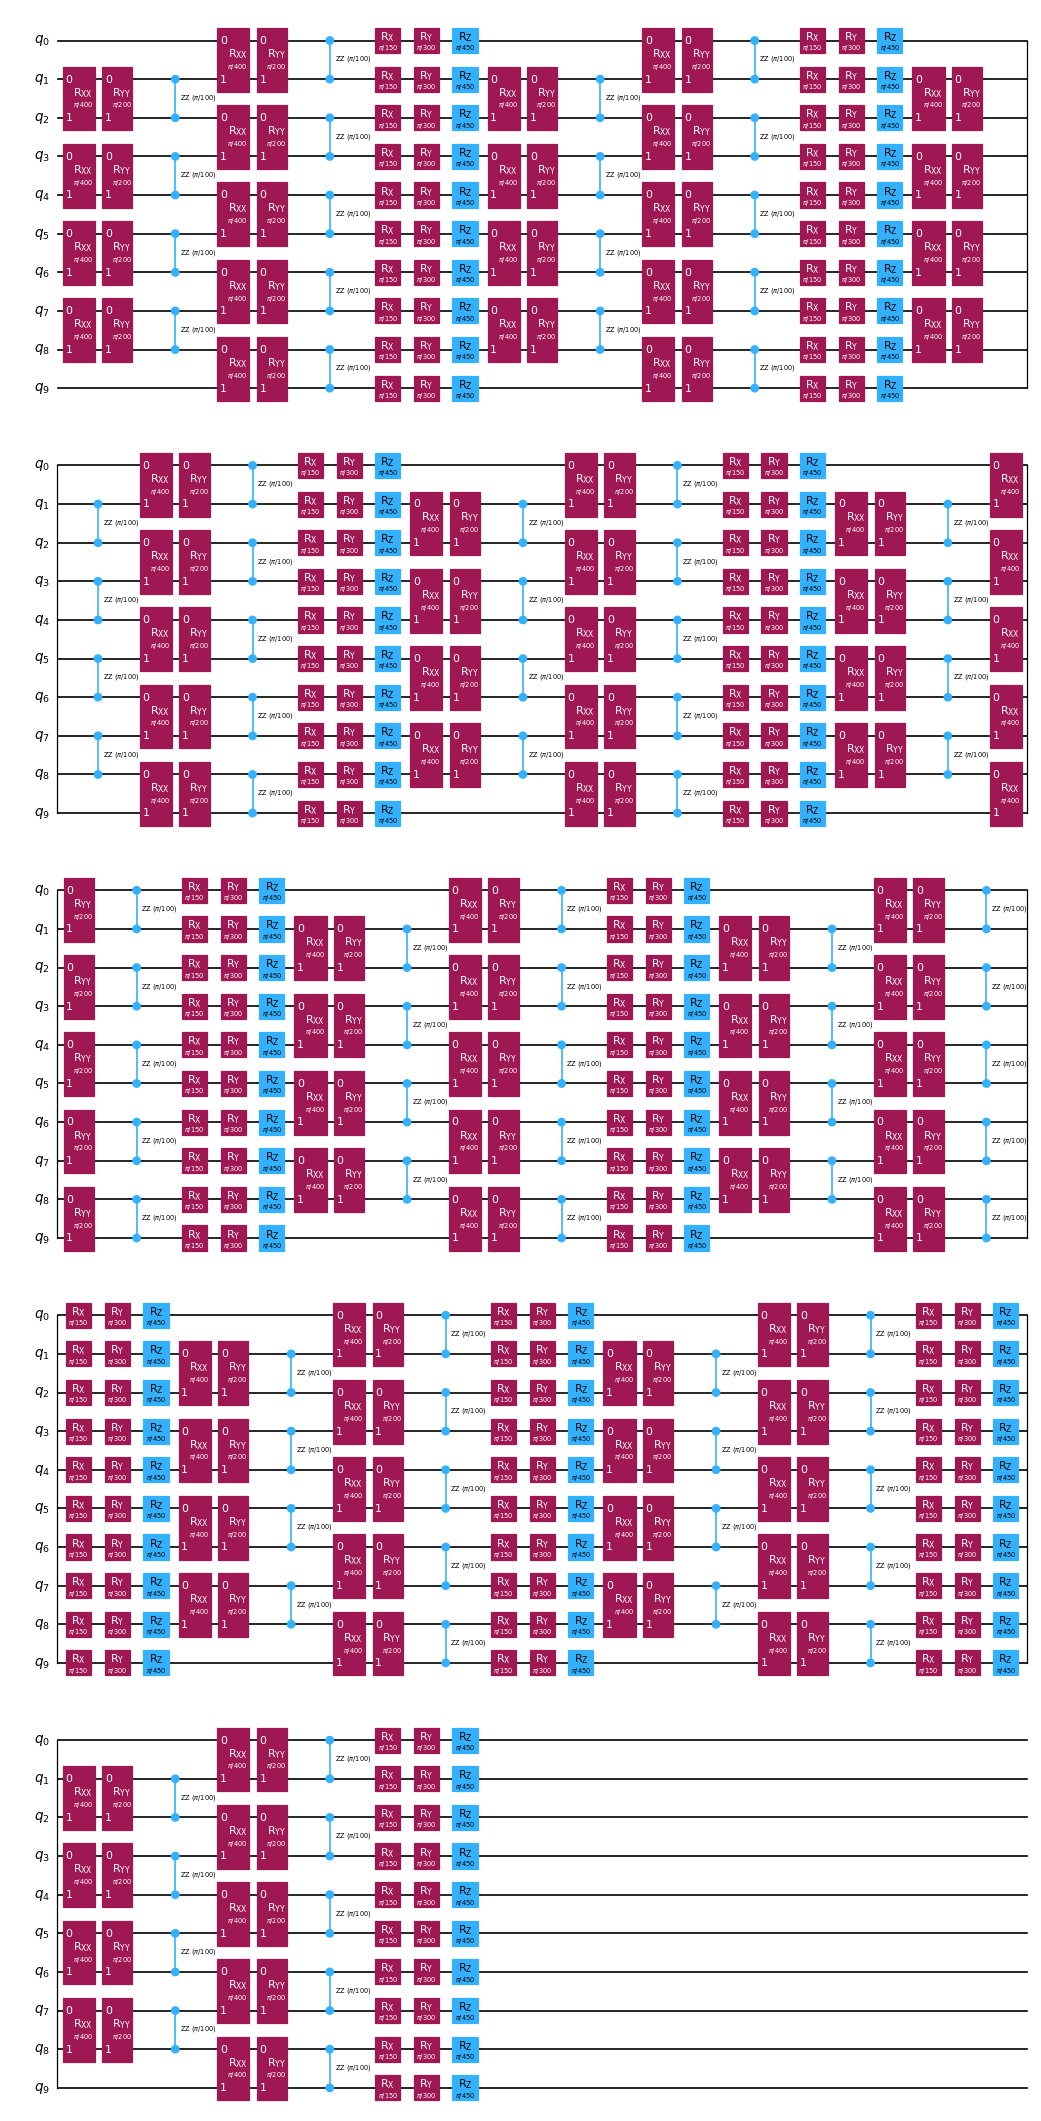

In [14]:
coupling_map = CouplingMap.from_heavy_hex(3, bidirectional=False)
reduced_coupling_map = coupling_map.reduce([0, 13, 1, 14, 10, 16, 5, 12, 8, 18])

hamiltonian = generate_xyz_hamiltonian(
                                        reduced_coupling_map,
                                        coupling_constants=(np.pi / 8, np.pi / 4, np.pi / 2),
                                        ext_magnetic_field=(np.pi / 3, np.pi / 6, np.pi / 9),
                                    )
circuit = generate_time_evolution_circuit(
                                            hamiltonian,
                                            time=0.1,
                                            synthesis=LieTrotter(reps=10),
                                        )
circuit.draw("mpl", style="iqp", scale=0.6)

86.33333333333333
Intersection at num_total_shots ≈ 7474.26
OBP-Shadow improvement is 0.15 times the minimum number of measurements for the coefficient truncation method.


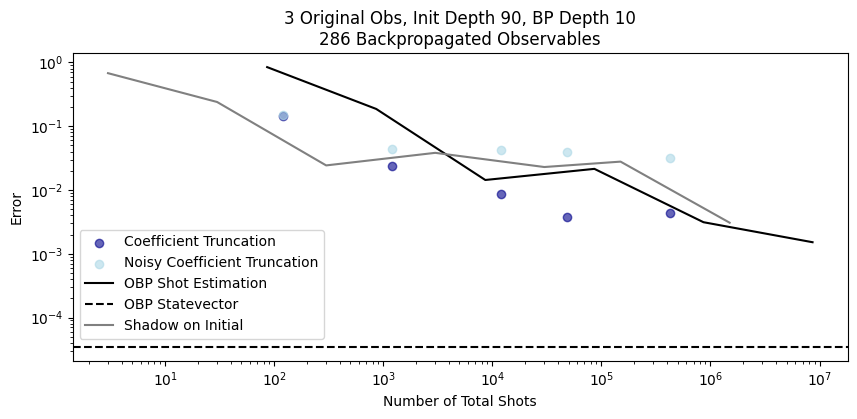

In [47]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data2'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs3.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs3.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs3.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_3.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 3
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

# y_hline = gb1['abs_total_error'].min()
y_hline = sorted(gb_noisy['abs_total_error'])[1]
# print(gb1[gb1['abs_total_error'] == y_hline])
y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [85]:
shad_df

,shad_exp,exact_val,shad_error,abs_shad_error,num_meas,obs_group
0,1.000000,0.943229,-0.056771,0.056771,3,0
1,-1.000000,0.149610,1.149610,1.149610,3,0
2,-1.000000,-0.174343,0.825657,0.825657,3,0
3,0.800000,0.943229,0.143229,0.143229,30,1
4,-0.200000,0.149610,0.349610,0.349610,30,1
5,-0.400000,-0.174343,0.225657,0.225657,30,1
6,0.960000,0.943229,-0.016771,0.016771,300,2
7,0.160000,0.149610,-0.010390,0.010390,300,2
8,-0.220000,-0.174343,0.045657,0.045657,300,2
9,0.951515,0.943229,-0.008286,0.008286,3000,3


82.0
Intersection at num_total_shots ≈ 321575.86
OBP-Shadow improvement is 3.61 times the minimum number of measurements for the coefficient truncation method.


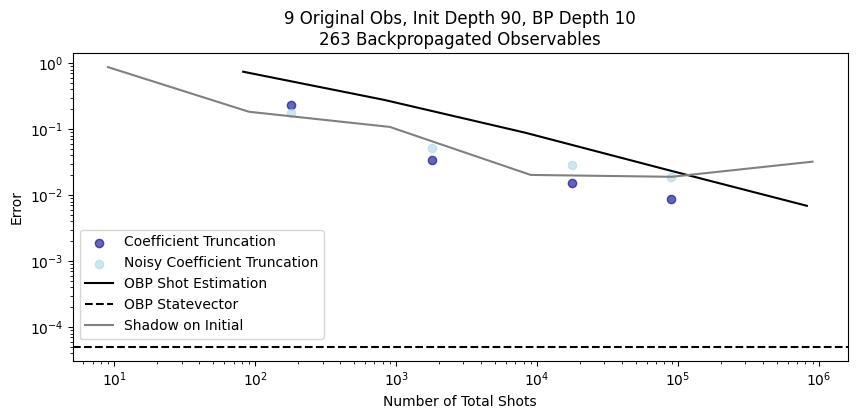

In [48]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data3'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs9.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs9.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs9.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_9.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 9
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb_noisy['abs_total_error'].min()
y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

154.0
Intersection at num_total_shots ≈ 619731.43
OBP-Shadow improvement is 3.61 times the minimum number of measurements for the coefficient truncation method.


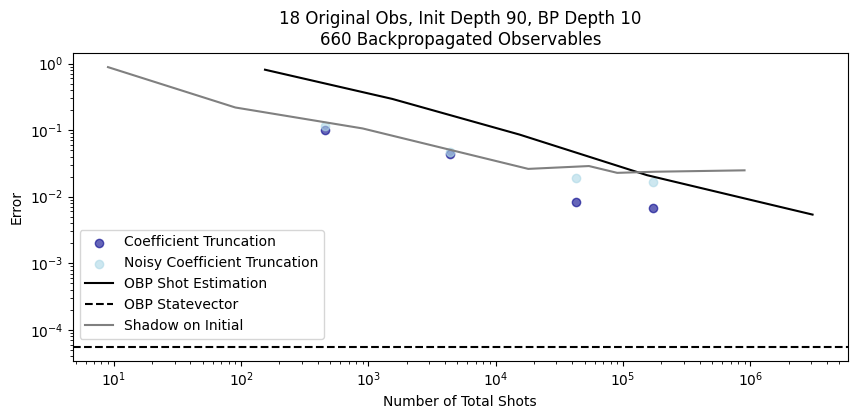

In [49]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data4'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs18.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs18.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs18.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_18.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 18
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb_noisy['abs_total_error'].min()
y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [37]:
def save_to_pickle(df, filename):
    """
    Save DataFrame to pickle file, appending if file already exists.
    
    Inputs:
    - df: pandas DataFrame - DataFrame to save
    - filename: str - output pickle filename
    
    Outputs:
    - None (writes to file)"""
    if os.path.exists(filename):
        df_old = pd.read_pickle(f'{filename}')
        df_combined = pd.concat([df_old, df], ignore_index=True)
    else:
        df_combined = df

    df_combined.to_pickle(f'{filename}')

In [41]:
save_to_pickle(obp_df[:-18], f'{data_path}/obp_bp10_obs18.pkl')

276.1111111111111
Intersection at num_total_shots ≈ 239724.01
OBP-Shadow improvement is 2.45 times the minimum number of measurements for the coefficient truncation method.


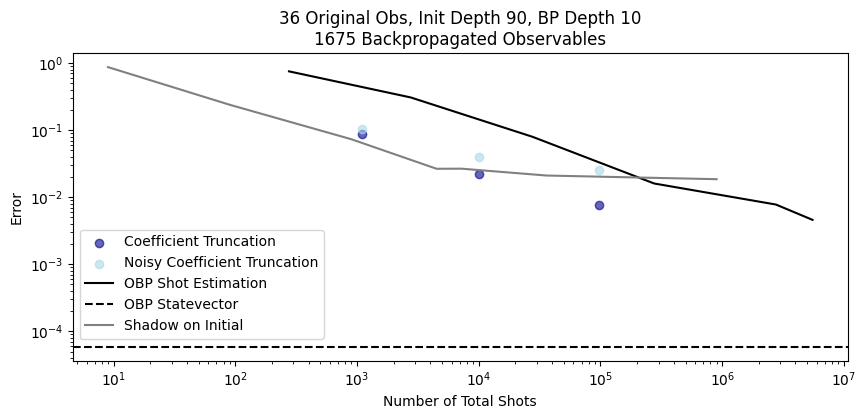

In [50]:
data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data5'))
noisy_data_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_noisy'))

coef_df = pd.read_pickle(f'{data_path}/coef-trunc_init90_bp10_obs36.pkl')
noisy_coef_df = pd.read_pickle(f'{noisy_data_path}/coef-trunc_init90_bp10_obs36.pkl')

# pauli_df = pd.read_pickle(f'{data_path}/pauli-trunc7_init90_bp5_obs9.pkl')
obp_df = pd.read_pickle(f'{data_path}/obp_bp10_obs36.pkl')
shad_df = pd.read_pickle(f'{data_path}/shad_res_36.pkl')

obp_df['num_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.paulis))
obp_df['num_qwc_bp_obs'] = obp_df['bp_obs'].apply(lambda x: len(x.group_commuting(qubit_wise=True)))
obp_df['num_total_shots'] = obp_df['num_qwc_bp_obs'] * obp_df['obp_shots']

obs_num = 36
coef_df['obs_group'] = coef_df.index // obs_num
noisy_coef_df['obs_group'] = noisy_coef_df.index // obs_num

obp_df['obs_group'] = obp_df.index // obs_num
shad_df['obs_group'] = shad_df.index // obs_num
# pauli_df['obs_group'] = pauli_df.index // obs_num

gb1 = coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()
gb_noisy = noisy_coef_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

# gb2 = pauli_df.groupby('obs_group').agg({'abs_total_error': 'mean', 'num_meas': 'mean'}).reset_index()

gb_obp = obp_df.groupby('obs_group').agg({'num_total_shots': 'mean', 'abs_bp_error_shots': 'mean'}).reset_index()

gb_shad = shad_df.groupby('num_meas').agg({'abs_shad_error': 'mean'}).reset_index()

plt.figure(figsize=(10, 4))

plt.scatter(x=gb1['num_meas'], y=gb1['abs_total_error'], label='Coefficient Truncation', alpha=0.6, color='darkblue')
plt.scatter(x=gb_noisy['num_meas'], y=gb_noisy['abs_total_error'], label='Noisy Coefficient Truncation', alpha=0.6, color='lightblue')

# plt.scatter(x=gb2['num_meas'], y=gb2['abs_total_error'], label='Pauli Weight Truncation (7)', alpha=0.6, color='lightblue')

sns.lineplot(data=gb_obp, x='num_total_shots', y='abs_bp_error_shots', label='OBP Shot Estimation', color='black')
plt.axhline(y=obp_df['abs_bp_error_state'].mean(), color='black', linestyle='--', label='OBP Statevector')
sns.lineplot(data=gb_shad, x='num_meas', y='abs_shad_error', label='Shadow on Initial', color='gray')

plt.xscale('log')
plt.yscale('log')
plt.title(f'{obs_num} Original Obs, Init Depth 90, BP Depth 10\n{int(math.ceil(obp_df["num_bp_obs"].mean()))} Backpropagated Observables')
plt.xlabel('Number of Total Shots')
plt.ylabel('Error')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.05))

print(obp_df['num_qwc_bp_obs'].mean())

y_hline = gb_noisy['abs_total_error'].min()
y_min = gb_noisy[gb_noisy['abs_total_error'] == y_hline]['num_meas'].values[0]
diff = gb_obp['abs_bp_error_shots'] - y_hline
crossings = diff.shift(-1) * diff < 0
for idx in gb_obp.index[crossings]:
    x0 = gb_obp.loc[idx, 'num_total_shots']
    y0 = gb_obp.loc[idx, 'abs_bp_error_shots']
    x1 = gb_obp.loc[idx + 1, 'num_total_shots']
    y1 = gb_obp.loc[idx + 1, 'abs_bp_error_shots']
    # Linear interpolation
    if y1 != y0:
        x_intersect = x0 + (y_hline - y0) * (x1 - x0) / (y1 - y0)
        print(f"Intersection at num_total_shots ≈ {x_intersect:.2f}")
        print(f"OBP-Shadow improvement is {x_intersect / y_min:.2f} times the minimum number of measurements for the coefficient truncation method.")

In [45]:
obp_df

,backpropagated slices,number of terms,number of groups,max error,error is bounded by,bp_obs,bp_circuit,obs,circuit,bp_circuit_depth,...,obp_shots,circuit_depth,abs_bp_error_shots,bp_error_shots,abs_bp_error_state,bp_error_state,num_bp_obs,num_qwc_bp_obs,num_total_shots,obs_group
0,80,248,79,0.0001,0.007996,"[[[SparsePauliOp(['ZZIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",ZZIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,0.311190,0.311190,0.000004,-0.000004,248,79,79,0
1,80,316,90,0.0001,0.007997,"[[[SparsePauliOp(['ZXIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",ZXIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,0.961106,0.961106,0.000062,-0.000062,316,90,90,0
2,80,293,90,0.0001,0.008000,"[[[SparsePauliOp(['ZYIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",ZYIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,1.655052,1.655052,0.000038,0.000038,293,90,90,0
3,80,275,84,0.0001,0.007998,"[[[SparsePauliOp(['XXIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",XXIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,1.236718,-1.236718,0.000006,-0.000006,275,84,84,0
4,80,204,65,0.0001,0.007997,"[[[SparsePauliOp(['XZIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",XZIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,1,90,0.261183,0.261183,0.000153,-0.000153,204,65,65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,80,3196,459,0.0001,0.007999,"[[[SparsePauliOp(['IIIXZIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIXZIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,10000,90,0.000600,0.000600,0.000021,0.000021,3196,459,4590000,4
176,80,3742,514,0.0001,0.008000,"[[[SparsePauliOp(['IIIXYIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIXYIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,10000,90,0.007524,0.007524,0.000027,-0.000027,3742,514,5140000,4
177,80,3530,484,0.0001,0.007996,"[[[SparsePauliOp(['IIIYYIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIYYIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,10000,90,0.010391,0.010391,0.000053,-0.000053,3530,484,4840000,4
178,80,2943,427,0.0001,0.007999,"[[[SparsePauliOp(['IIIYZIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",IIIYZIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",10,...,10000,90,0.003028,-0.003028,0.000055,0.000055,2943,427,4270000,4


In [ ]:
# plot the expectation value compared with theh weight (weight on x-axis, expectation value on y-axis)
# try to work out why the pauli weight might tend towards 0 when the ground state is not 0

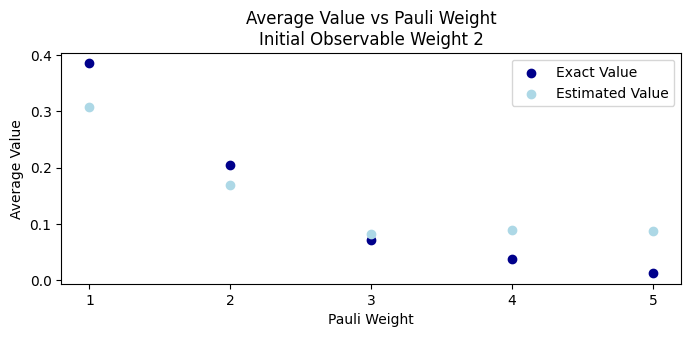

In [12]:
data_weight_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_weight'))
data_weight = pd.read_pickle(f'{data_weight_path}/coef-trunc_init90_bp30_obs1_weight2.pkl')

xyestimate = {}
xyexact = {}
xycount = {}

for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in xyexact:
        xyexact[len([x for x in d['obs'] if x != 'I'])] = abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] = abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        xyexact[len([x for x in d['obs'] if x != 'I'])] += abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] += abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] += 1

for k in xyexact:
    xyexact[k] = xyexact[k] / xycount[k]
    xyestimate[k] = xyestimate[k] / xycount[k]

plt.figure(figsize=(8, 3))

plt.scatter(xyexact.keys(), xyexact.values(), color='darkblue', label='Exact Value')
plt.scatter(xyestimate.keys(), xyestimate.values(), color='lightblue', label='Estimated Value')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Average Value')
plt.title('Average Value vs Pauli Weight\nInitial Observable Weight 2')
plt.legend()

In [13]:
data_weight

,backpropagated slices,number of terms,number of groups,max error,error is bounded by,bp_obs,bp_circuit,obs,circuit,bp_circuit_depth,...,total_exp,obs_shad_dict,num_meas,circuit_depth,abs_bp_error_shots,bp_error_shots,abs_bp_error_state,bp_error_state,abs_total_error,total_error
0,60,145,45,0.0001,0.005994,"[[[SparsePauliOp(['ZZIIIIIIII'],\n ...","((Instruction(name='rxx', num_qubits=2, num_cl...",ZZIIIIIIII,"((Instruction(name='rxx', num_qubits=2, num_cl...",30,...,0.988933,"[{'obs': 'ZZIIIIIIII', 'estimate': 1.0, 'exact...",4507,90,0.002501,0.002501,0.000022,-0.000022,0.045704,-0.045704


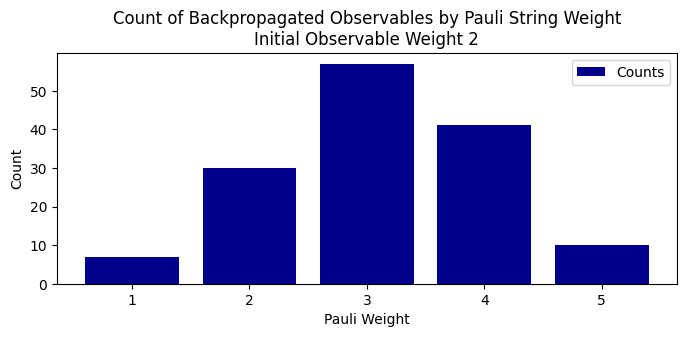

In [100]:
p = {}
for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in p:
        p[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        p[len([x for x in d['obs'] if x != 'I'])] += 1

plt.figure(figsize=(8, 3))

plt.bar(p.keys(), p.values(), color='darkblue', label='Counts')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Count')
plt.title('Count of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

{2: np.complex128(1.1393525963904148+2.8231713756259034e-18j), 3: np.complex128(-0.03165709638978114+2.1245279549260933e-18j), 4: np.complex128(-0.011575155559541857+1.0056360248748202e-20j), 1: np.complex128(0.030723496905243713+8.335226899513356e-19j), 5: np.complex128(0.0001874245839340396+1.1383560806944145e-21j)}


/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


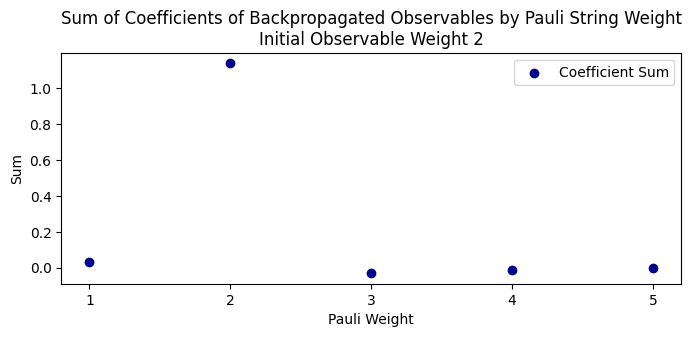

In [101]:
coef_dict = {}
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in coef_dict:
        coef_dict[len([x for x in str(p) if x != 'I'])] = c
    else:
        coef_dict[len([x for x in str(p) if x != 'I'])] += c

print(coef_dict)
plt.figure(figsize=(8, 3))

plt.scatter(coef_dict.keys(), coef_dict.values(), color='darkblue', label='Coefficient Sum')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Sum of Coefficients of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_14725/3499375961.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_14725/3499375961.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_14725/3499375961.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_sh

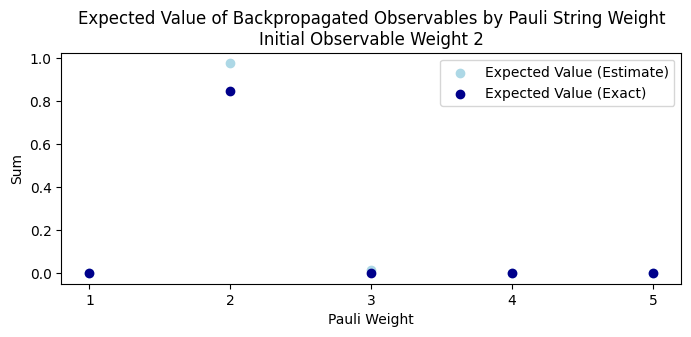

In [15]:
# estimated expected value by pauli weight
# exact expected value by pauli weight
# scatter plot
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in ev_est_dict:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
    else:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])

# print(ev_est_dict)
plt.figure(figsize=(8, 3))

plt.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value (Estimate)')
plt.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value (Exact)')

plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Expected Value of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 2')
plt.legend()

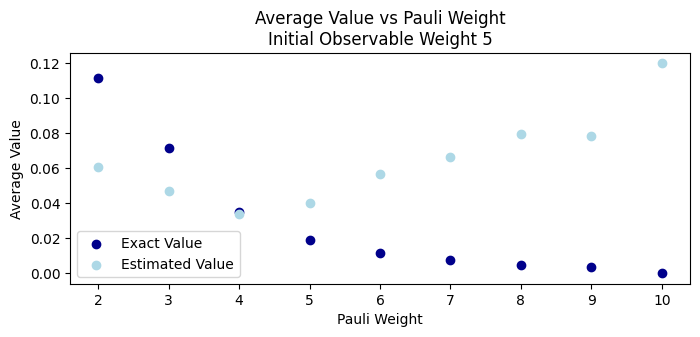

In [95]:
data_weight_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'data_weight'))
data_weight = pd.read_pickle(f'{data_weight_path}/coef-trunc_init90_bp30_obs1_weight5.pkl')

xyestimate = {}
xyexact = {}
xycount = {}

for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in xyexact:
        xyexact[len([x for x in d['obs'] if x != 'I'])] = abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] = abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        xyexact[len([x for x in d['obs'] if x != 'I'])] += abs(d['exact'])
        xyestimate[len([x for x in d['obs'] if x != 'I'])] += abs(d['estimate'])
        xycount[len([x for x in d['obs'] if x != 'I'])] += 1

for k in xyexact:
    xyexact[k] = xyexact[k] / xycount[k]
    xyestimate[k] = xyestimate[k] / xycount[k]

plt.figure(figsize=(8, 3))

plt.scatter(xyexact.keys(), xyexact.values(), color='darkblue', label='Exact Value')
plt.scatter(xyestimate.keys(), xyestimate.values(), color='lightblue', label='Estimated Value')

# plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Average Value')
plt.title('Average Value vs Pauli Weight\nInitial Observable Weight 5')
plt.legend()

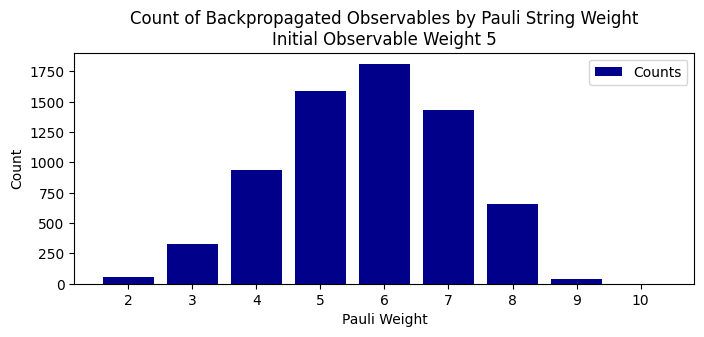

In [96]:
p = {}
for d in data_weight['obs_shad_dict'][0]:

    if len([x for x in d['obs'] if x != 'I']) not in p:
        p[len([x for x in d['obs'] if x != 'I'])] = 1
    else:
        p[len([x for x in d['obs'] if x != 'I'])] += 1

plt.figure(figsize=(8, 3))

plt.bar(p.keys(), p.values(), color='darkblue', label='Counts')

plt.xticks([2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Count')
plt.title('Count of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()

{5: np.complex128(1.3676646802669399-1.6499166033741534e-18j), 6: np.complex128(-0.043692765503451726-5.08985435937726e-18j), 8: np.complex128(0.00025799160886913697-7.061384058191809e-21j), 3: np.complex128(0.000870079189753865+3.527361294252975e-18j), 4: np.complex128(0.13010102656863579-1.4421266620606477e-18j), 7: np.complex128(-0.014040079585263+2.806663941952231e-18j), 2: np.complex128(2.687289376194744e-05+1.0354988920817205e-19j), 9: np.complex128(3.882593025408344e-05+1.4917786291845668e-22j), 10: np.complex128(-2.308236766836145e-07+0j)}


/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/qiskit-obp/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


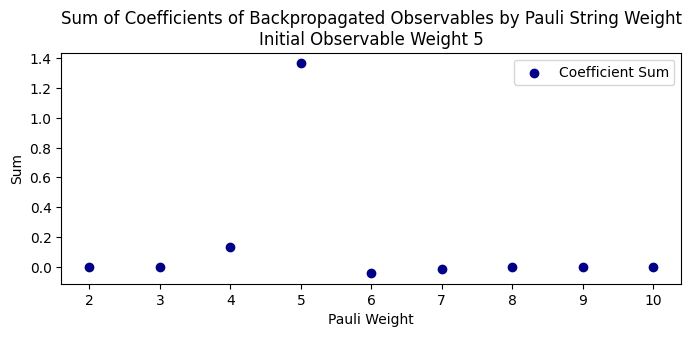

In [97]:
coef_dict = {}
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in coef_dict:
        coef_dict[len([x for x in str(p) if x != 'I'])] = c
    else:
        coef_dict[len([x for x in str(p) if x != 'I'])] += c

print(coef_dict)
plt.figure(figsize=(8, 3))

plt.scatter(coef_dict.keys(), coef_dict.values(), color='darkblue', label='Coefficient Sum')

# plt.xticks([1, 2, 3, 4, 5])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Sum of Coefficients of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()

/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_2630/2571598098.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_2630/2571598098.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
/var/folders/zw/x8tsqxcx3lzdfvcr_bhldgg80000gn/T/ipykernel_2630/2571598098.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_

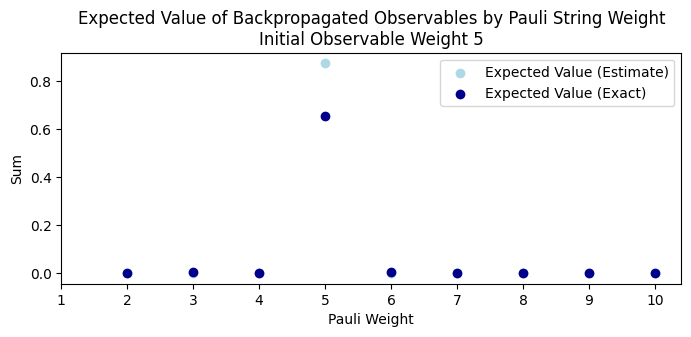

In [98]:
# estimated expected value by pauli weight
# exact expected value by pauli weight
# scatter plot
ev_est_dict = {}
ev_exact_dict = {}
obs_shad_df = pd.DataFrame(data_weight['obs_shad_dict'][0])
for p, c in zip(data_weight['bp_obs'][0].paulis, data_weight['bp_obs'][0].coeffs):
    if len([x for x in str(p) if x != 'I']) not in ev_est_dict:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] = c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])
    else:
        ev_est_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['estimate'])
        ev_exact_dict[len([x for x in str(p) if x != 'I'])] += c.real * float(obs_shad_df[obs_shad_df['obs'] == str(p)]['exact'])

# print(ev_est_dict)
plt.figure(figsize=(8, 3))

plt.scatter(ev_est_dict.keys(), ev_est_dict.values(), color='lightblue', label='Expected Value (Estimate)')
plt.scatter(ev_exact_dict.keys(), ev_exact_dict.values(), color='darkblue', label='Expected Value (Exact)')

plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

plt.xlabel('Pauli Weight')
plt.ylabel('Sum')
plt.title('Expected Value of Backpropagated Observables by Pauli String Weight\nInitial Observable Weight 5')
plt.legend()